In [183]:
import pandas as pd
import os
import matplotlib.pyplot as plot
import seaborn as sns

pd.set_option("mode.copy_on_write", True)

In [184]:
def parse_number(s):
    if pd.isna(s):
        return None
    s = str(s).strip().upper()
    if s.endswith("K"):
        return float(s[:-1]) * 1_000
    elif s.endswith("M"):
        return float(s[:-1]) * 1_000_000
    elif s.endswith("B"):
        return float(s[:-1]) * 1_000_000_000
    else:
        return float(s)


def get_property_damage_value(dataset):

    dataset["DAMAGE_PROPERTY"] = dataset["DAMAGE_PROPERTY"].apply(
        lambda x: (
            "1K"
            if pd.notna(x) and x == "K"
            else ("1M" if pd.notna(x) and x == "M" else x)
        )
    )

    dataset["DAMAGE_PROPERTY_VALUE"] = dataset["DAMAGE_PROPERTY"].apply(parse_number)

    print(len(dataset[dataset["DAMAGE_PROPERTY_VALUE"] > 0]))

    dataset["COUNT"] = dataset.groupby(["CZ_NAME", "YEAR"])["CZ_NAME"].transform(
        "count"
    )
    dataset["DAMAGE_PROPERTY_VALUE"] = dataset["DAMAGE_PROPERTY_VALUE"].fillna(0)
    dataset["DAMAGE_PROPERTY_VALUE"] = dataset["DAMAGE_PROPERTY_VALUE"].astype(float)

    # Step 3. Group by COUNTY and summarize
    county_summary = (
        dataset.groupby(["CZ_NAME", "YEAR"], as_index=False)
        .agg(
            {
                "COUNT": "first",
                "CZ_FIPS": "first",
                "STATE": "first",
                "STATE_FIPS": "first",
                "DAMAGE_PROPERTY_VALUE": "sum",
                "COUNT": "first",
            }
        )
        .rename(columns={"DAMAGE_PROPERTY_VALUE": "TOTAL_DAMAGE_PROPERTY"})
    )

    return county_summary

In [185]:
data_files = [
    f
    for f in os.listdir("../../01_original_data/fema_storm_data/")
    if f.endswith(".parquet")
]

storm = pd.concat(
    [
        pd.read_parquet(os.path.join("../../01_original_data/fema_storm_data/", f))
        for f in data_files
    ],
    axis=0,
    ignore_index=True,
)

storm = storm.drop(storm[storm["CZ_TYPE"] == "M"].index)
storm = storm.drop(storm[storm["STATE_FIPS"].isna()].index)

storm["STATE_FIPS"] = storm["STATE_FIPS"].astype(int).astype(str).str.zfill(2)
storm["CZ_FIPS"] = storm["CZ_FIPS"].astype(int).astype(str).str.zfill(3)

storm.head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,200111,28,600,200111,29,1800,1124964.0,5274875,TEXAS,48,...,NaN,None,None,NaN,NaN,NaN,NaN,Late on the 26th and on the 27th an arctic col...,Cooperative observer reported one inch of snow.,PDS
2,200112,1,900,200112,1,1800,1125247.0,5275049,NEW JERSEY,34,...,NaN,None,None,NaN,NaN,NaN,NaN,A strong ridge of high pressure over the weste...,None,PDS
3,200111,29,600,200111,29,1800,1124964.0,5274877,TEXAS,48,...,NaN,None,None,NaN,NaN,NaN,NaN,Late on the 26th and on the 27th an arctic col...,A mixture of freezing rain and sleet made brid...,PDS
4,200111,15,800,200111,30,800,1125105.0,5274892,SOUTH CAROLINA,45,...,NaN,None,None,NaN,NaN,NaN,NaN,None,The South Carolina Drought Response Committee ...,PDS
5,200111,15,800,200111,30,800,1125105.0,5274893,SOUTH CAROLINA,45,...,NaN,None,None,NaN,NaN,NaN,NaN,None,None,PDS


In [186]:
flood = storm[storm["EVENT_TYPE"].str.contains("flood", case=False)]
flood = get_property_damage_value(flood)
flood_state = (
    flood[flood["YEAR"] >= 2000]
    .groupby("STATE")
    .agg({"TOTAL_DAMAGE_PROPERTY": "sum", "COUNT": "sum"})
    .sort_values(by="TOTAL_DAMAGE_PROPERTY", ascending=False)
)
flood_state

58966


,TOTAL_DAMAGE_PROPERTY,COUNT
STATE,,
TEXAS,3.481679e+10,12692
NEW JERSEY,2.180304e+10,3118
PUERTO RICO,1.934210e+10,3126
PENNSYLVANIA,9.984414e+09,5458
LOUISIANA,7.443182e+09,2891
MISSOURI,6.136124e+09,9711
CALIFORNIA,4.659023e+09,6239
NORTH CAROLINA,4.237780e+09,4620
INDIANA,3.676078e+09,5751


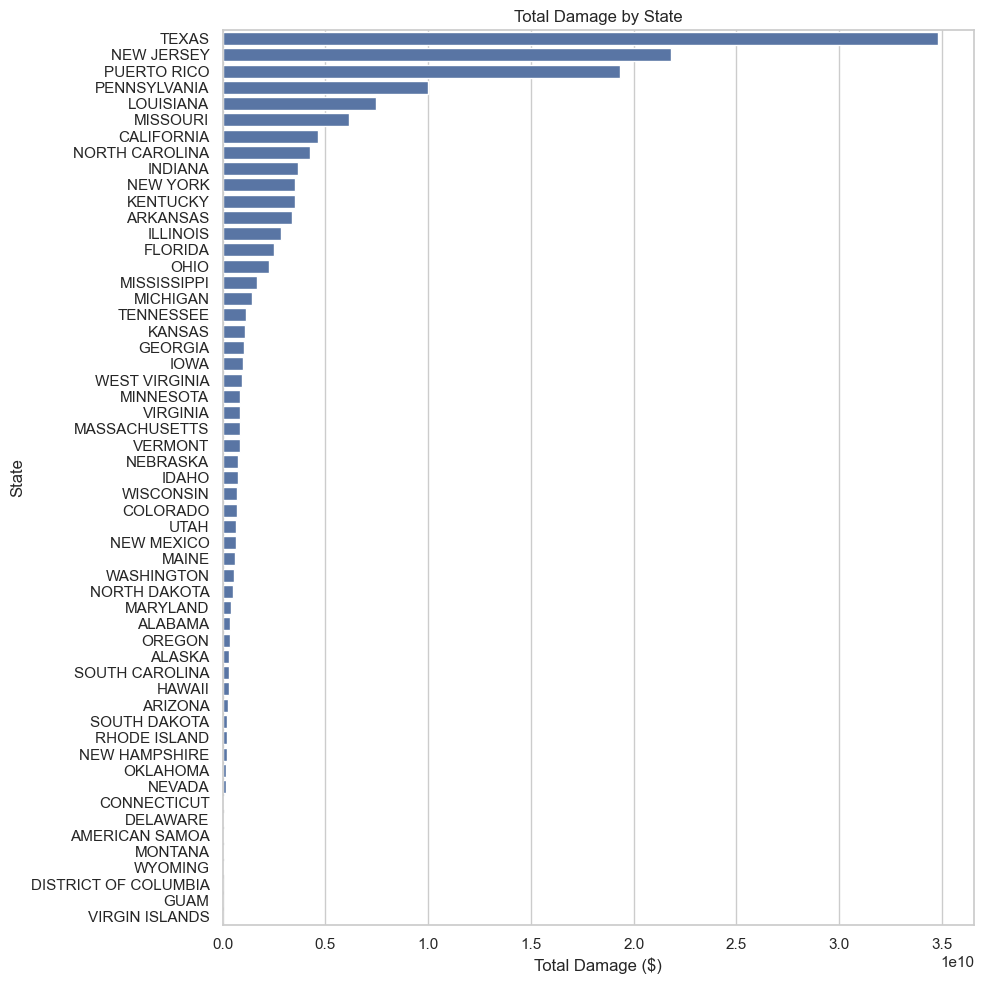

In [187]:
sns.set_theme(style="whitegrid")
plot.figure(figsize=(10, 10))
plot.title("Total Damage by State")
plot.xlabel("Total Damage ($)")
plot.ylabel("State")
sns.barplot(y=flood_state.index, x=flood_state["TOTAL_DAMAGE_PROPERTY"])
plot.tight_layout()
plot.show()

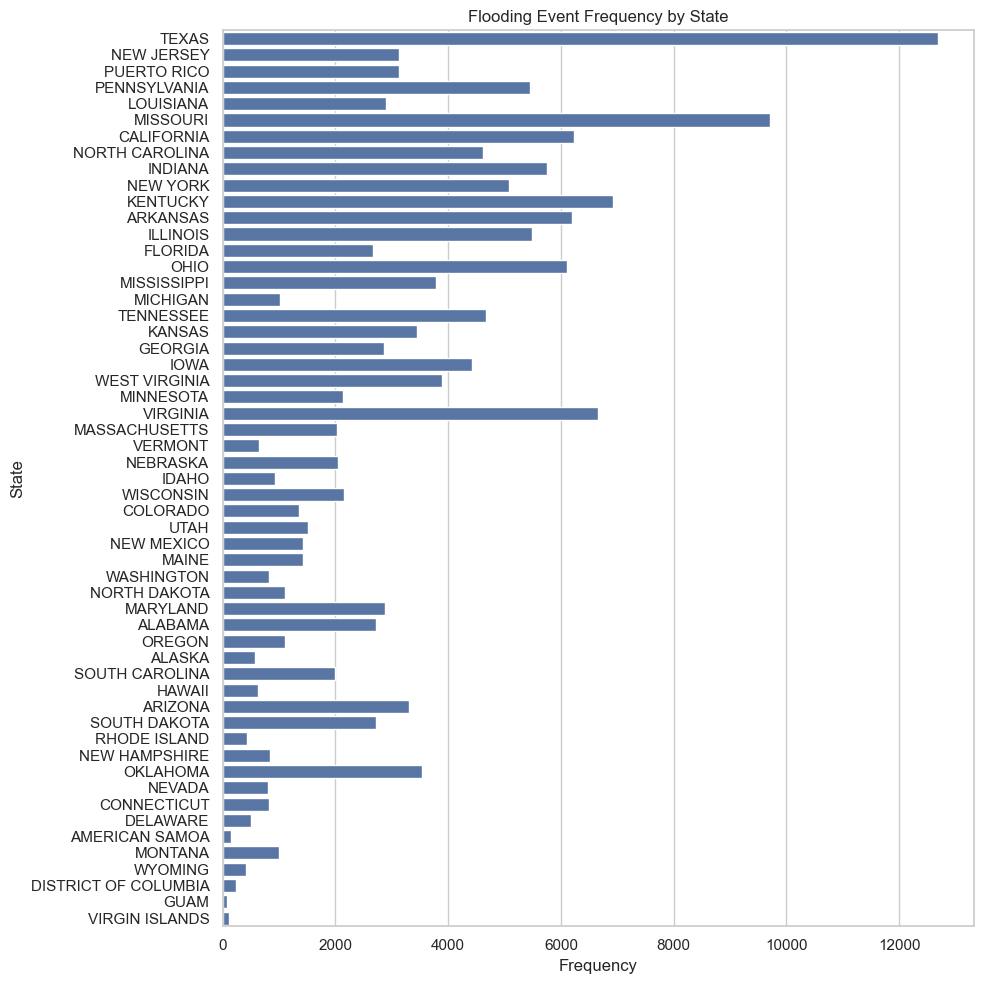

In [188]:
plot.figure(figsize=(10, 10))
plot.title("Flooding Event Frequency by State")
plot.ylabel("State")
plot.xlabel("Frequency")
sns.barplot(y=flood_state.index, x=flood_state["COUNT"])
plot.tight_layout()
plot.show()

In [189]:
# flood_state_melted = flood_state.reset_index().melt(
#     id_vars=["STATE"],
#     value_vars=["TOTAL_DAMAGE_PROPERTY", "COUNT"],
#     var_name="metric",
#     value_name="value"
# )

# g = sns.catplot(
#     data=flood_state_melted,
#     kind="bar",
#     x="value",         # numeric (horizontal)
#     y="STATE",        # category
#     hue="metric",      # one color for each metric (sales, profit)
#     # col="category",    # facet by another variable
#     height=3.5,
#     aspect=1.1,
#     dodge=True
# )

# g.set_axis_labels("Value", "Region")
# g.set_titles("Category: {col_name}")
# g.despine(left=True)
# plot.show()

In [191]:
# tornado = storm[storm["EVTYPE"].str.contains("tornado", case=False)]
# fire = storm[storm["EVTYPE"].str.contains("fire", case=False)]